<h1>Analisis actividad 11: Running</h1>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import seaborn as sns


In [2]:
actividad = 11

In [3]:
actividades = {
    1: "Standing still",
    2: "Sitting and relaxing",
    3: "Lying down",
    4: "Walking",
    5: "Climbing stairs",
    6: "Waist bends forward",
    7: "Frontal elevation of arms",
    8: "Knees bending",
    9: "Cycling",
    10: "Jogging",
    11: "Running",
    12: "Jump front & back"
}

<h1>Carga de Dataset</h1>

In [4]:

import glob
import pandas as pd
import re

# Busca todos los archivos
files = glob.glob(r"../DataSets/MHEALTHDATASET/mHealth_subject*.log")

dfs = []

for file in files:
    
    # Extraer número de sujeto desde el nombre del archivo
    subject_id = int(re.search(r"subject(\d+)", file).group(1))
    
    # Leer archivo
    df = pd.read_csv(file, sep='\t', header=None)
    
    # Agregar columna subject_id
    df["subject_id"] = subject_id
    
    dfs.append(df)

# Unir todos
MHEALTHDATASET = pd.concat(dfs, ignore_index=True)

# Asignar nombres de columnas
MHEALTHDATASET.columns = [  
    # Chest sensor
    "chest_acc_x",
    "chest_acc_y",
    "chest_acc_z",
    "ecg_1",
    "ecg_2",

    # Left ankle
    "ankle_acc_x",
    "ankle_acc_y",
    "ankle_acc_z",
    "ankle_gyro_x",
    "ankle_gyro_y",
    "ankle_gyro_z",
    "ankle_mag_x",
    "ankle_mag_y",
    "ankle_mag_z",

    # Right lower arm
    "arm_acc_x",
    "arm_acc_y",
    "arm_acc_z",
    "arm_gyro_x",
    "arm_gyro_y",
    "arm_gyro_z",
    "arm_mag_x",
    "arm_mag_y",
    "arm_mag_z",

    # Label
    "activity_label",
    
    # Nuevo
    "subject_id"
]

pd.set_option('display.max_columns', None)


In [5]:
## Filtramos para mostrar la actividad 
DATASET_ACTIVIDAD = MHEALTHDATASET[MHEALTHDATASET['activity_label'] == actividad]

# Le quitamos las etiquetas
DATASET_SENSORES_ACTIVIDAD = DATASET_ACTIVIDAD.drop(columns=['activity_label'])

<h1>Correlación entre los atributos</h1>

In [6]:

DATASET_SENSORES_ACTIVIDAD.corr()

,chest_acc_x,chest_acc_y,chest_acc_z,ecg_1,ecg_2,ankle_acc_x,ankle_acc_y,ankle_acc_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,arm_acc_x,arm_acc_y,arm_acc_z,arm_gyro_x,arm_gyro_y,arm_gyro_z,arm_mag_x,arm_mag_y,arm_mag_z,subject_id
chest_acc_x,1.000000,0.113757,0.362188,0.050756,-0.021104,0.011162,-0.134837,-0.039080,0.010149,-0.175452,0.134925,-0.006195,-0.058821,-0.006261,0.460489,0.247432,-0.123141,0.031493,0.082288,0.004115,0.053257,0.089117,0.001429,0.043107
chest_acc_y,0.113757,1.000000,0.032707,0.026301,-0.040369,0.015802,0.031993,0.286238,-0.101763,0.138877,-0.312811,-0.158207,0.037438,0.057199,-0.084222,0.411473,0.056796,-0.154087,-0.081690,-0.067369,-0.094095,-0.149658,0.250982,0.010075
chest_acc_z,0.362188,0.032707,1.000000,-0.077300,-0.074817,0.024677,-0.058000,-0.145794,-0.106624,-0.154761,-0.031198,0.209877,0.004117,-0.019373,0.199703,0.044687,-0.139845,-0.029816,0.197978,-0.065443,-0.059204,-0.053909,0.060595,-0.167083
ecg_1,0.050756,0.026301,-0.077300,1.000000,0.510172,0.018504,-0.003612,0.049066,0.071435,0.030967,-0.066366,-0.018471,-0.005273,0.033271,-0.074810,-0.022939,0.068181,0.023892,-0.171383,-0.036384,0.048300,-0.006665,0.029100,-0.043322
ecg_2,-0.021104,-0.040369,-0.074817,0.510172,1.000000,-0.014994,0.001110,0.020846,0.116624,0.010348,0.007227,0.021289,0.006501,-0.020689,-0.071534,-0.093223,0.093176,0.074258,-0.186922,0.057821,0.030411,-0.000243,0.006948,-0.054051
ankle_acc_x,0.011162,0.015802,0.024677,0.018504,-0.014994,1.000000,-0.039646,-0.169552,-0.171314,0.017617,-0.037109,-0.028316,-0.252255,0.073632,0.064596,0.073155,-0.029438,-0.014945,-0.063905,-0.171883,-0.018505,-0.040059,-0.009348,0.104783
ankle_acc_y,-0.134837,0.031993,-0.058000,-0.003612,0.001110,-0.039646,1.000000,-0.163341,-0.070108,0.311067,-0.028885,0.122079,-0.006991,-0.100938,-0.099458,-0.233977,-0.096100,-0.006724,0.092415,0.036298,-0.154160,-0.206636,0.119546,-0.023684
ankle_acc_z,-0.039080,0.286238,-0.145794,0.049066,0.020846,-0.169552,-0.163341,1.000000,-0.057113,0.134727,-0.409865,-0.274788,-0.039262,0.169546,-0.379269,0.461903,0.192513,-0.126254,-0.285320,-0.163568,0.134619,0.015203,0.208312,0.046957
ankle_gyro_x,0.010149,-0.101763,-0.106624,0.071435,0.116624,-0.171314,-0.070108,-0.057113,1.000000,-0.320502,0.278536,-0.062008,-0.085337,0.086566,0.027310,-0.096852,0.180990,-0.160746,0.074270,0.593862,0.285120,0.182604,-0.211012,-0.093441
ankle_gyro_y,-0.175452,0.138877,-0.154761,0.030967,0.010348,0.017617,0.311067,0.134727,-0.320502,1.000000,-0.359960,0.098691,0.178946,0.153588,-0.234541,-0.059507,-0.265461,0.208080,-0.264389,-0.282709,-0.360033,-0.293281,0.281068,0.039376


<h1>Histograma de la Actividad</h1>

<function matplotlib.pyplot.show(close=None, block=None)>

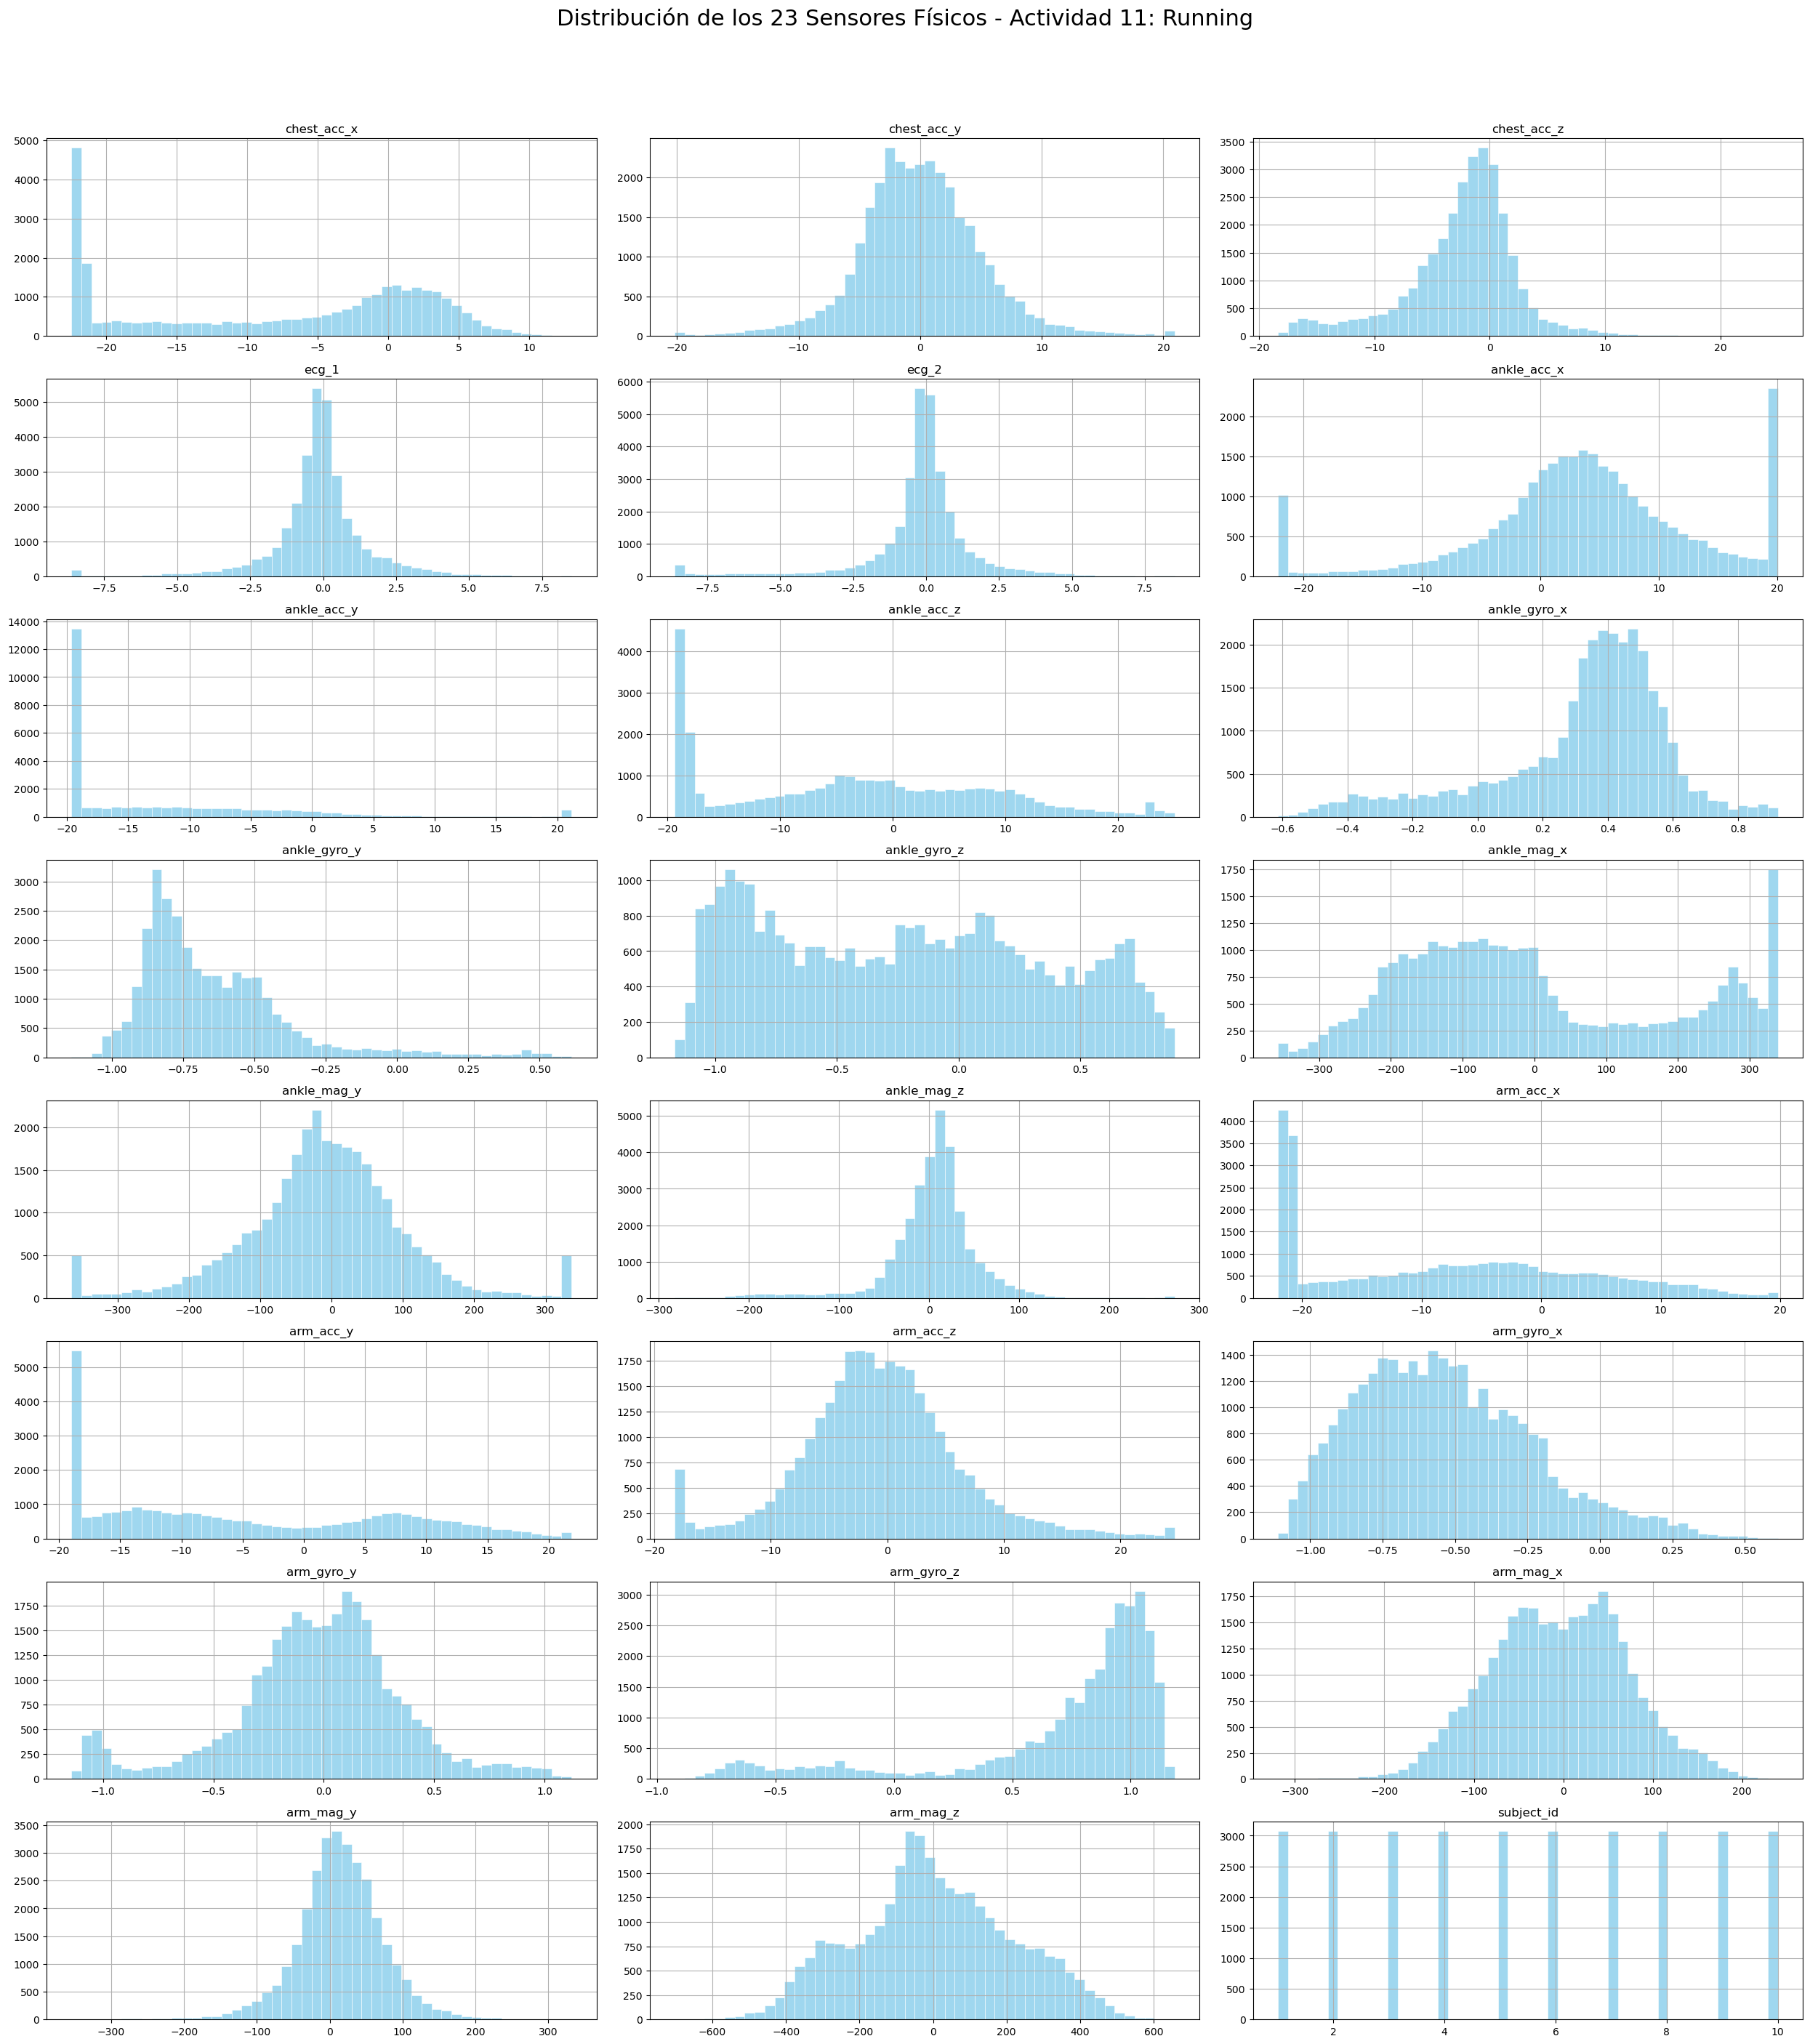

In [7]:


DATASET_SENSORES_ACTIVIDAD.hist(
    bins=50, 
    layout=(15,3),
    figsize=(25, 50), 
    color='skyblue', 
    edgecolor='white', 
    linewidth=0.5,
    alpha=0.8
)

plt.suptitle(f"Distribución de los 23 Sensores Físicos - Actividad {actividad}: {actividades[actividad]}", fontsize=22, y=1.02)
plt.tight_layout()

plt.show

<h1>Outliers</h1>

In [8]:

outliers_info = []

for col in DATASET_SENSORES_ACTIVIDAD.select_dtypes(include="number").columns:
    
    Q1 = DATASET_SENSORES_ACTIVIDAD[col].quantile(0.25)
    Q3 = DATASET_SENSORES_ACTIVIDAD[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    mask_outliers = (DATASET_SENSORES_ACTIVIDAD[col] < lower) | (DATASET_SENSORES_ACTIVIDAD[col] > upper)
    
    total_outliers = mask_outliers.sum()
    percentage = mask_outliers.mean() * 100
    
    outliers_info.append({
        "Sensor": col,
        "Total_Outliers": total_outliers,
        "Porcentaje_Outliers (%)": round(percentage, 2)
    })

outliers_df = pd.DataFrame(outliers_info)

outliers_df

,Sensor,Total_Outliers,Porcentaje_Outliers (%)
0,chest_acc_x,0,0.00
1,chest_acc_y,1044,3.40
2,chest_acc_z,2250,7.32
3,ecg_1,3879,12.63
4,ecg_2,4583,14.92
5,ankle_acc_x,1416,4.61
6,ankle_acc_y,886,2.88
7,ankle_acc_z,0,0.00
8,ankle_gyro_x,2297,7.48
9,ankle_gyro_y,1489,4.85


<h1>Gráfica de densidad</h1>

<function matplotlib.pyplot.show(close=None, block=None)>

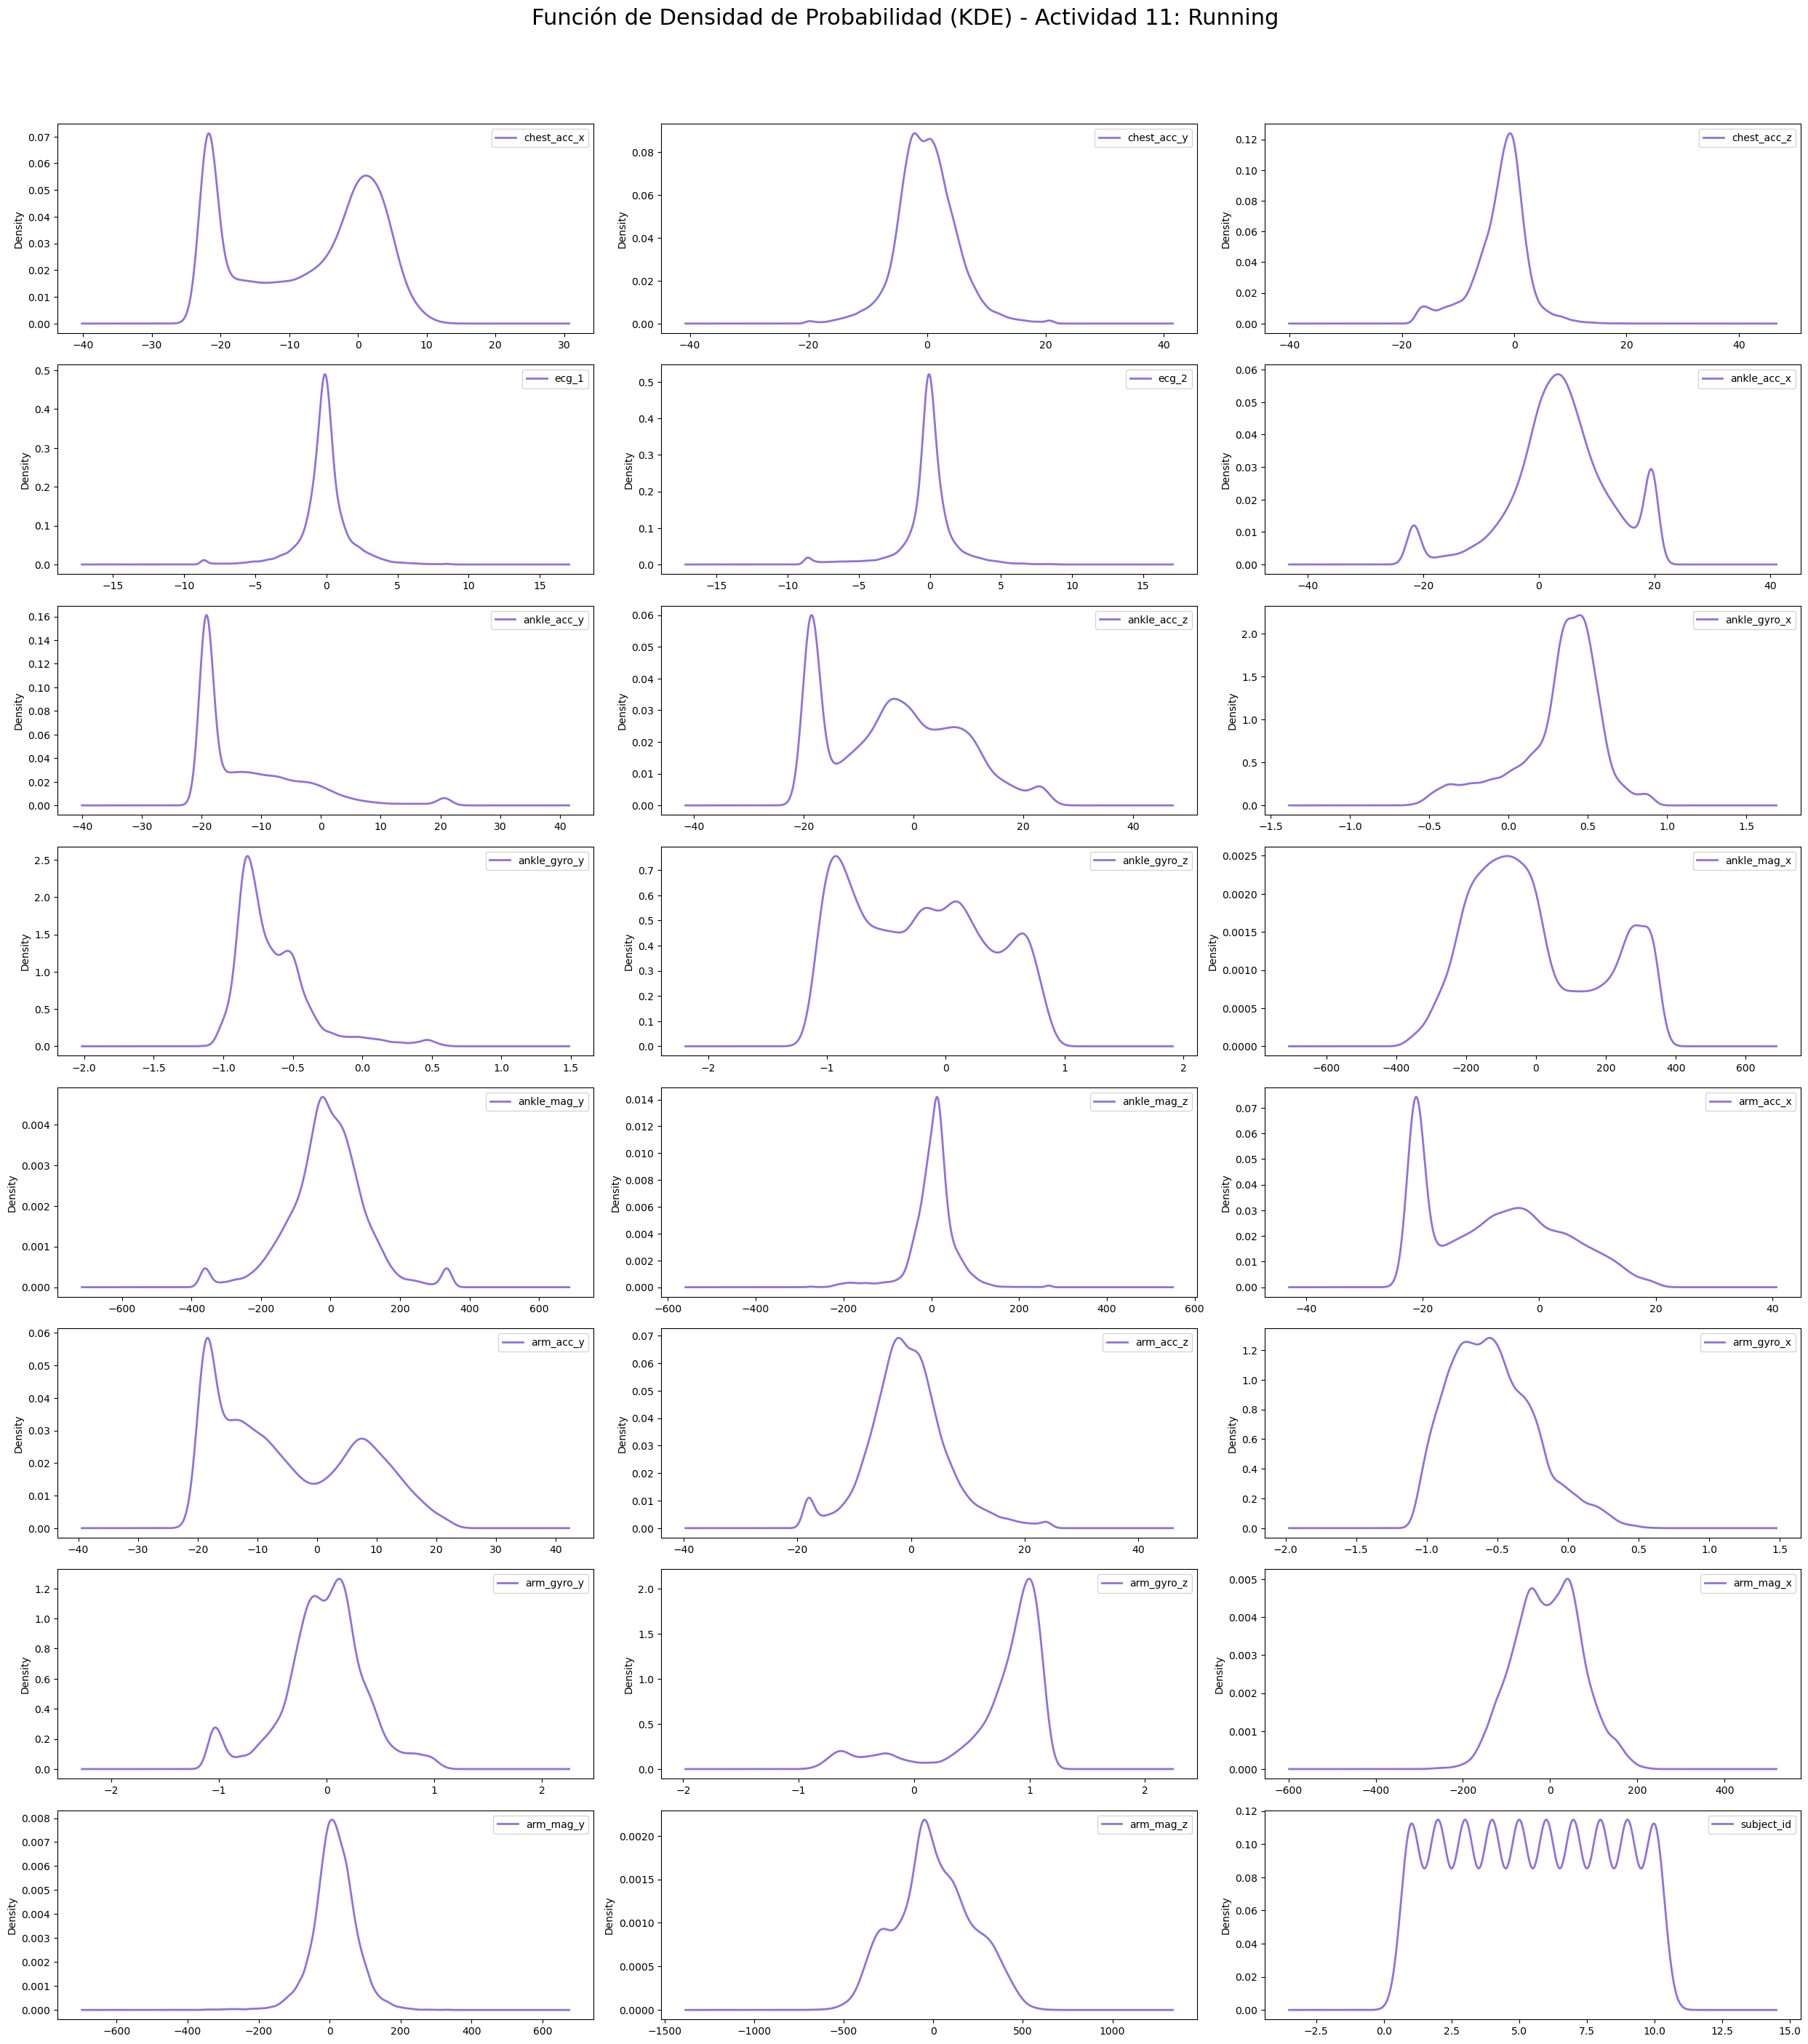

In [9]:
DATASET_SENSORES_ACTIVIDAD.plot(
    kind='density', 
    subplots=True, 
    layout=(15, 3),  
    figsize=(25, 50),
    sharex=False,     
    color='mediumpurple', 
    linewidth=2
)

plt.suptitle(f"Función de Densidad de Probabilidad (KDE) - Actividad {actividad}: {actividades[actividad]}", fontsize=22, y=1.02)
plt.tight_layout()

plt.show

<h1>Gráfica de cajas y bigotes</h1>

<function matplotlib.pyplot.show(close=None, block=None)>

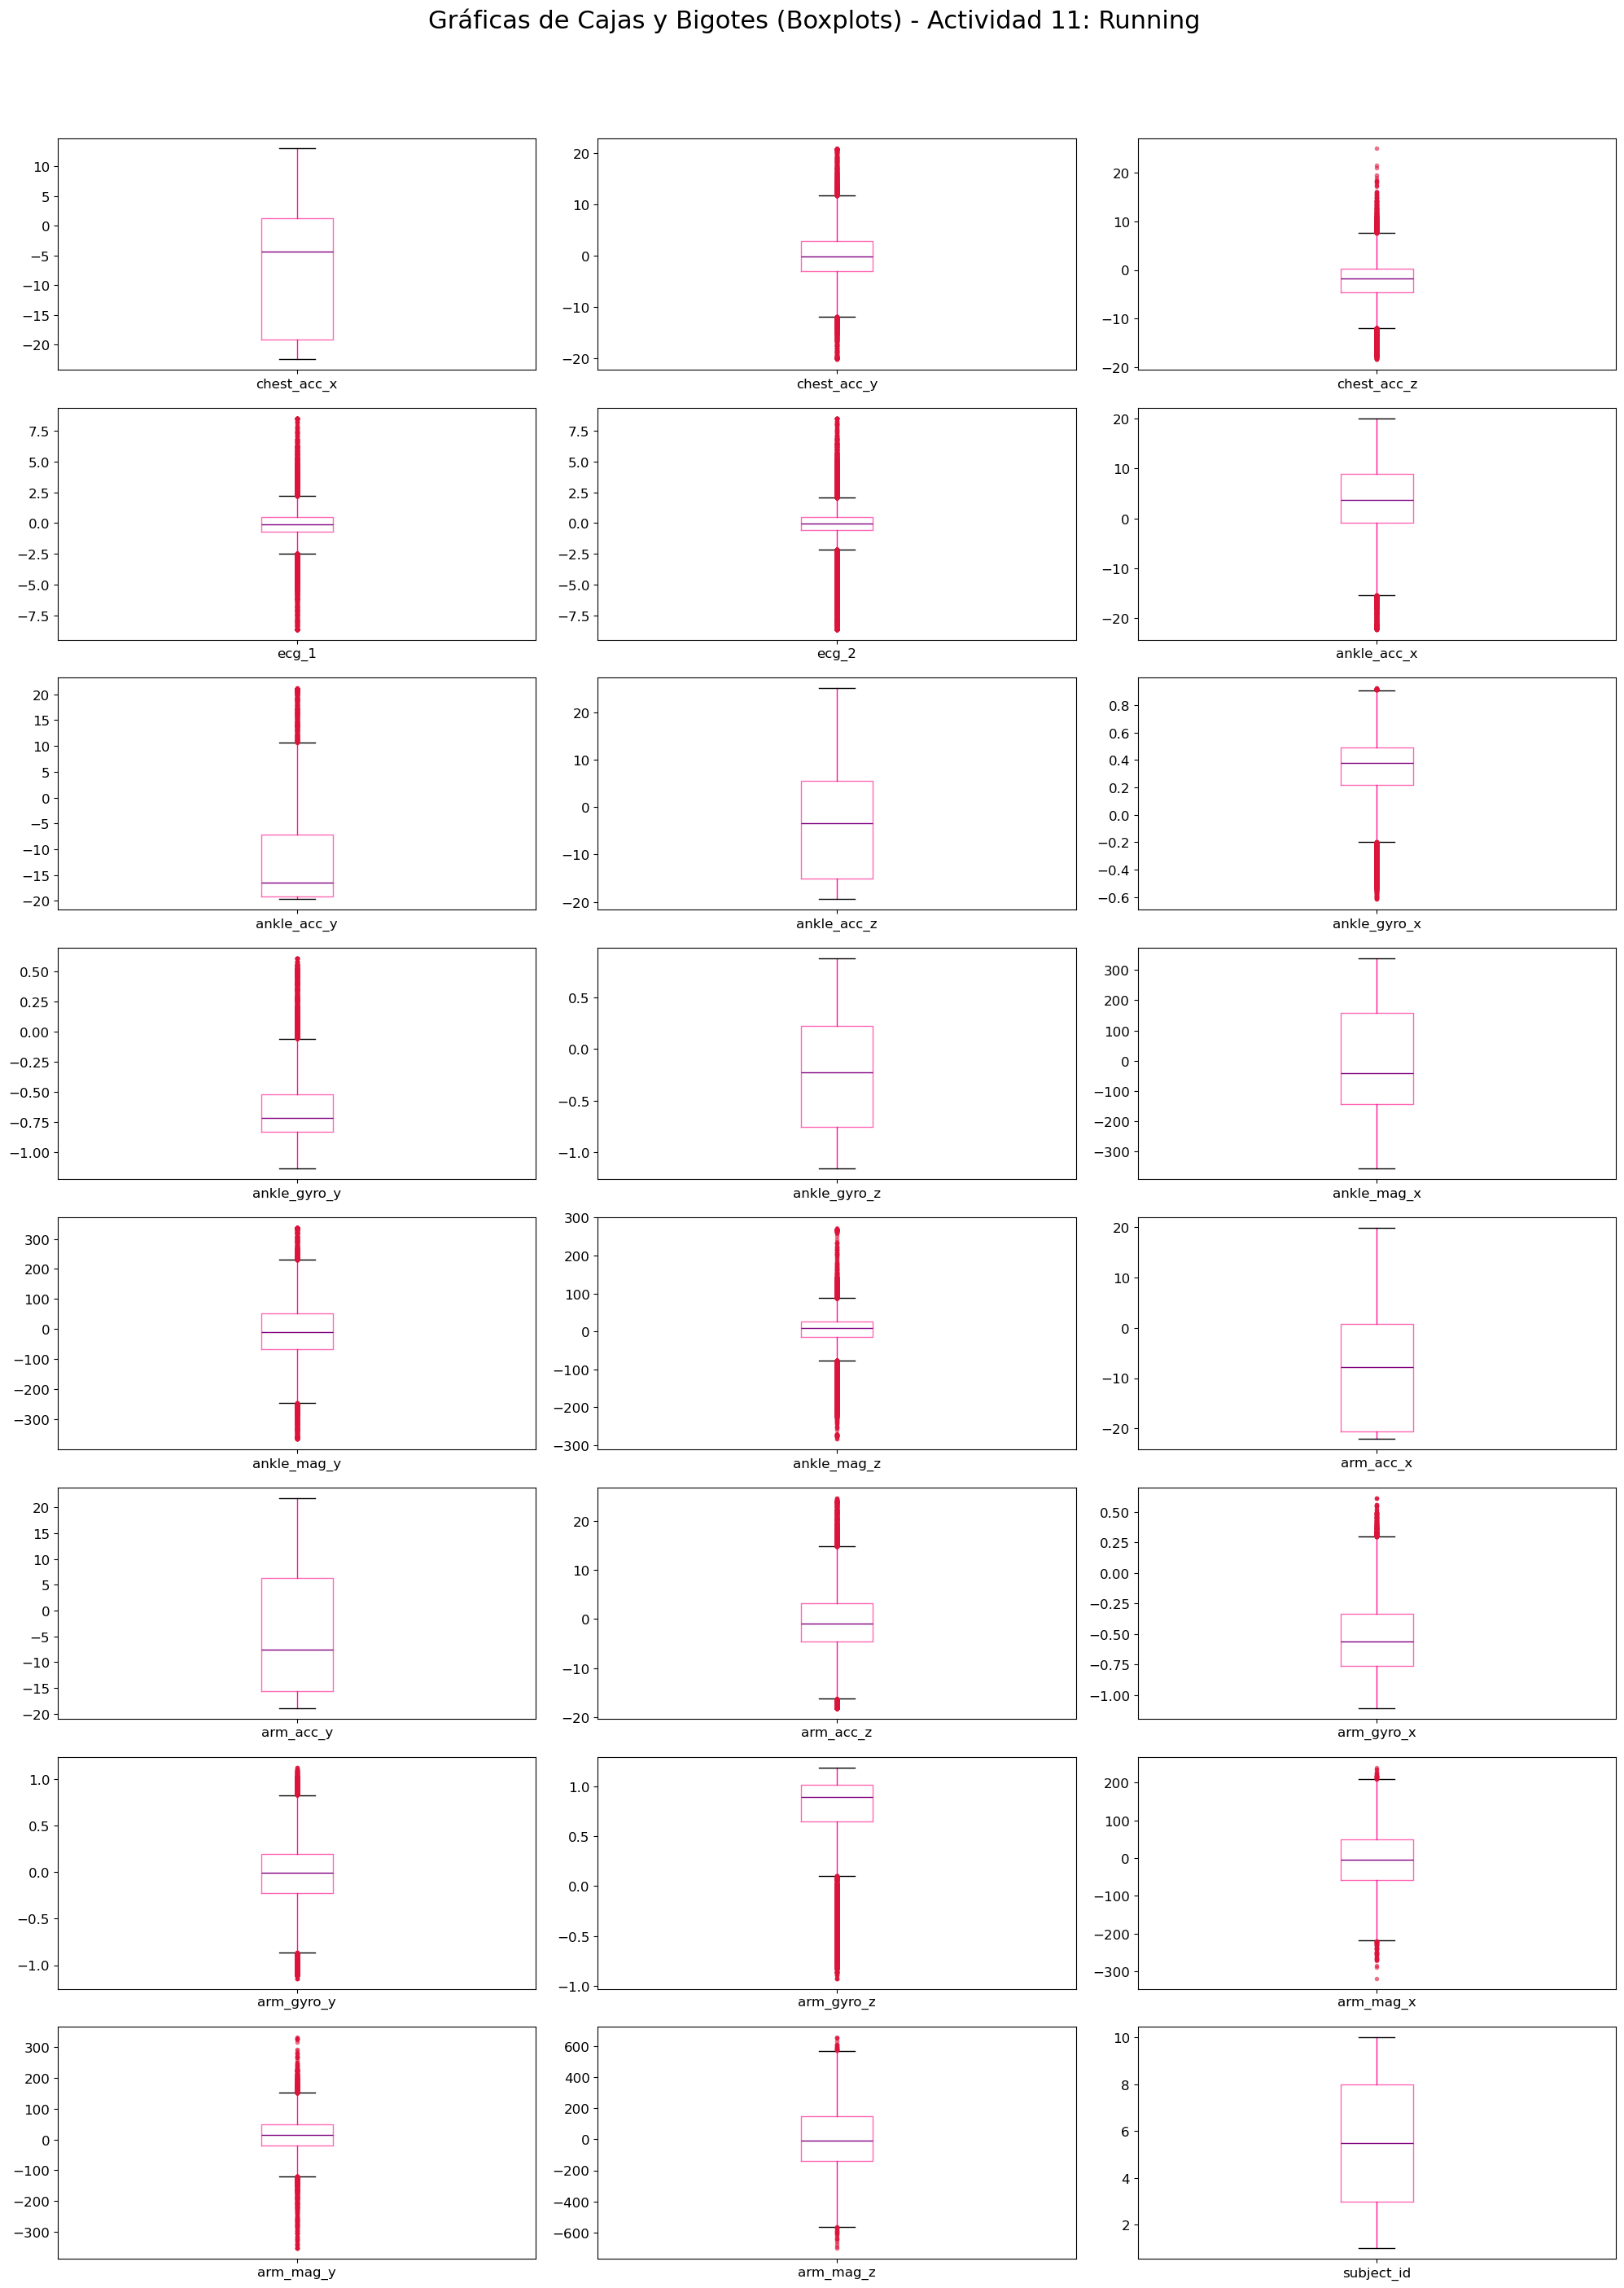

In [10]:
color_props = dict(boxes='hotpink', whiskers='deeppink', medians='purple', caps='black')
puntitos_props = dict(marker='o', markerfacecolor='crimson', markersize=4, alpha=0.6, markeredgecolor='none')

# Dibujamos el mosaico
DATASET_SENSORES_ACTIVIDAD.plot(
    kind='box', 
    subplots=True, 
    layout=(15, 3),  
    figsize=(20, 50), 
    color=color_props,
    flierprops=puntitos_props,
    fontsize=12      
)


plt.suptitle(f'Gráficas de Cajas y Bigotes (Boxplots) - Actividad {actividad}: {actividades[actividad]}', fontsize=22, y=1.02)
plt.tight_layout()

plt.show

<h1>Matriz de correlación</h1>

<function matplotlib.pyplot.show(close=None, block=None)>

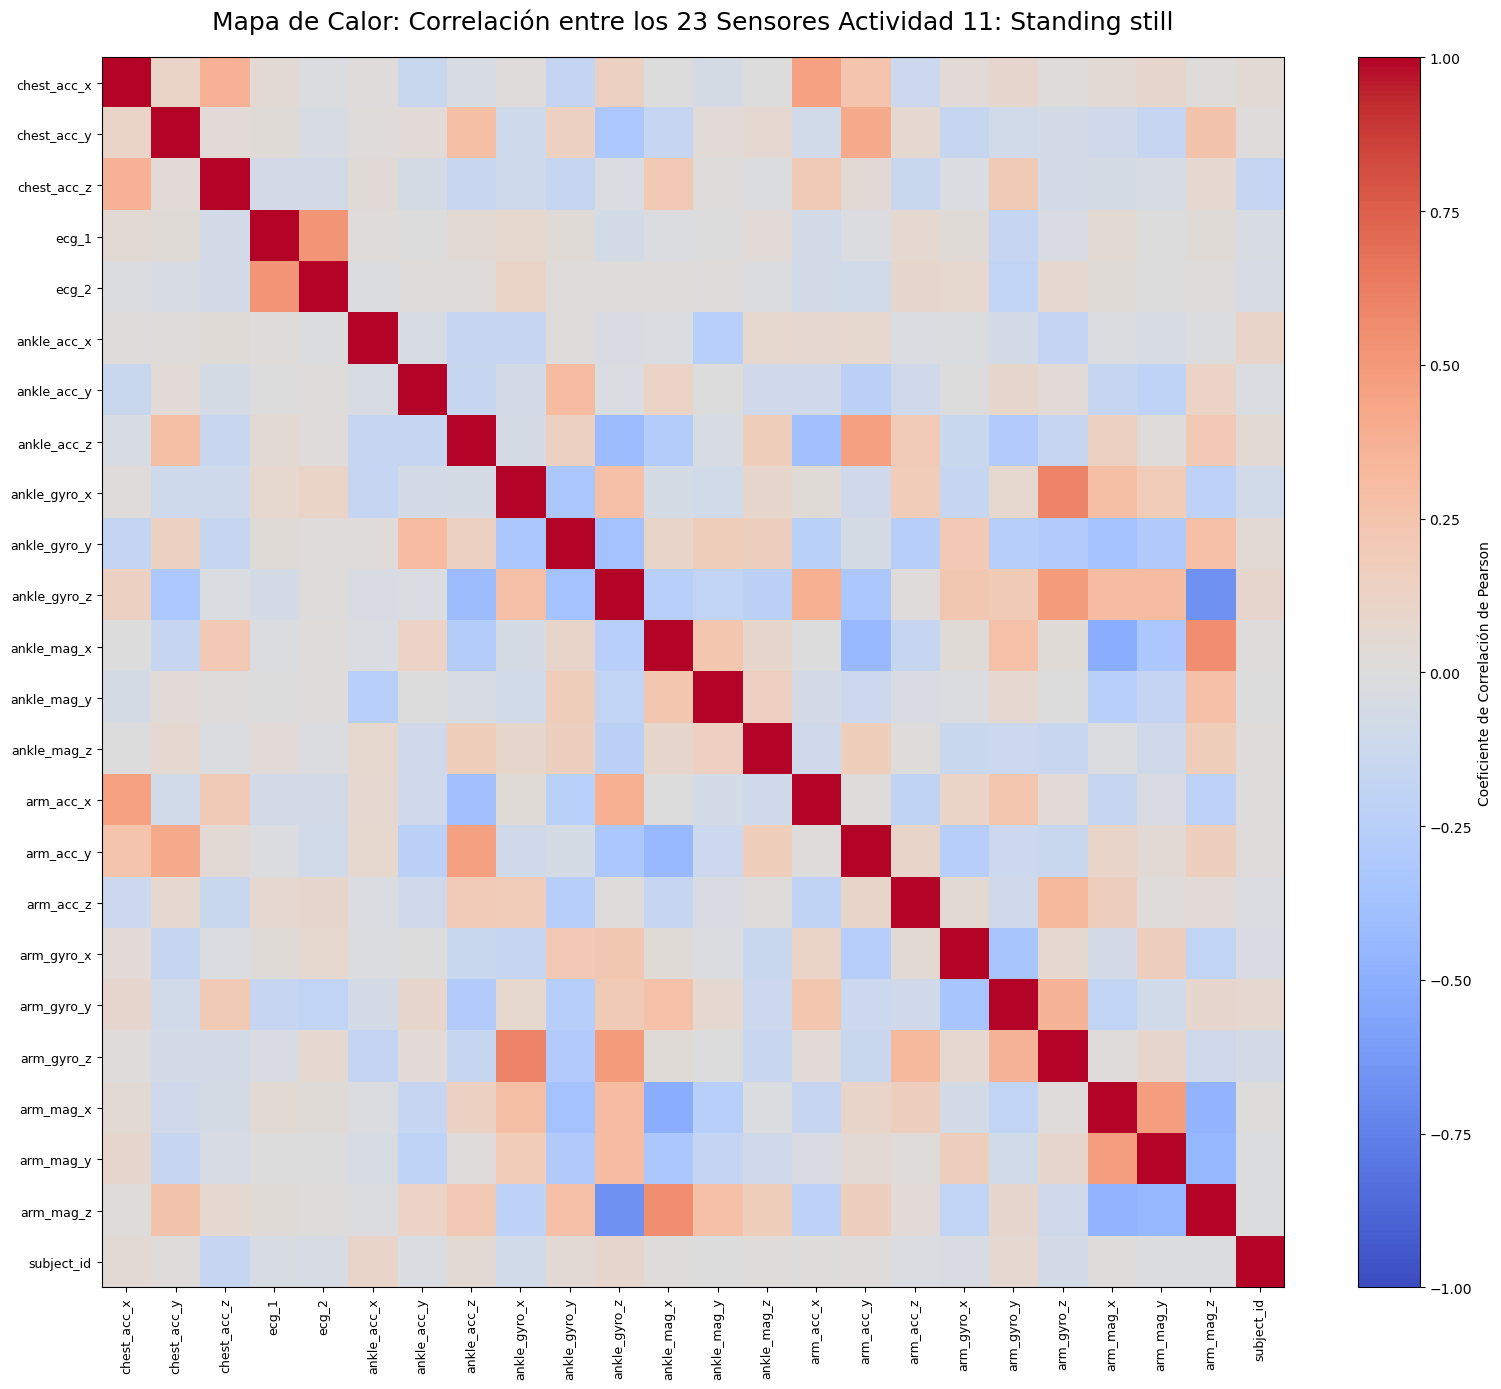

In [11]:
# Calculamos la matriz de correlación de Pearson
matriz_correlacion = DATASET_SENSORES_ACTIVIDAD.corr()

# Dibujamos el Mapa de Calor
plt.figure(figsize=(16, 14))

# Usamos imshow para dibujar la cuadrícula, coolwarm da rojo a los +1 y azul a los -1
imagen = plt.imshow(matriz_correlacion, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')

# Agregamos la barra de colores al lado
plt.colorbar(imagen, label='Coeficiente de Correlación de Pearson')
plt.title(f'Mapa de Calor: Correlación entre los 23 Sensores Actividad {actividad}: {actividades[1]}', fontsize=18, pad=20)

# Ponemos los nombres de las 45 columnas en los bordes
posiciones = np.arange(len(DATASET_SENSORES_ACTIVIDAD.columns))
plt.xticks(posiciones, DATASET_SENSORES_ACTIVIDAD.columns, rotation=90, fontsize=9)
plt.yticks(posiciones, DATASET_SENSORES_ACTIVIDAD.columns, fontsize=9)

plt.grid(False) 
plt.tight_layout()

plt.show

<h1>Matriz de dispersión</h1>

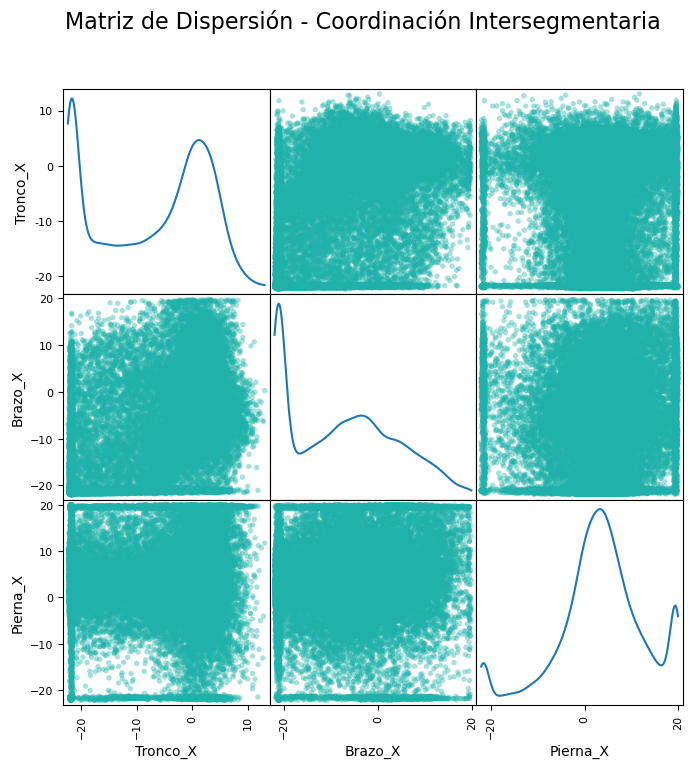

In [12]:
# Selección estratégica: un eje X por segmento corporal
sensores_estrategicos = [
    "chest_acc_x",   # Tronco
    "arm_acc_x",     # Brazo derecho
    "ankle_acc_x"    # Pierna
]

datos_scatter = DATASET_SENSORES_ACTIVIDAD[sensores_estrategicos].copy()


datos_scatter.columns = [
    "Tronco_X",
    "Brazo_X",
    "Pierna_X"
]

pd.plotting.scatter_matrix(
    datos_scatter,
    alpha=0.4,
    figsize=(8, 8),
    diagonal='kde',
    color='lightseagreen',
    marker='o',
    s=15
)

plt.suptitle(
    'Matriz de Dispersión - Coordinación Intersegmentaria',
    fontsize=16
)

plt.show()

<h1>Matriz de dispersión por sujeto</h1>

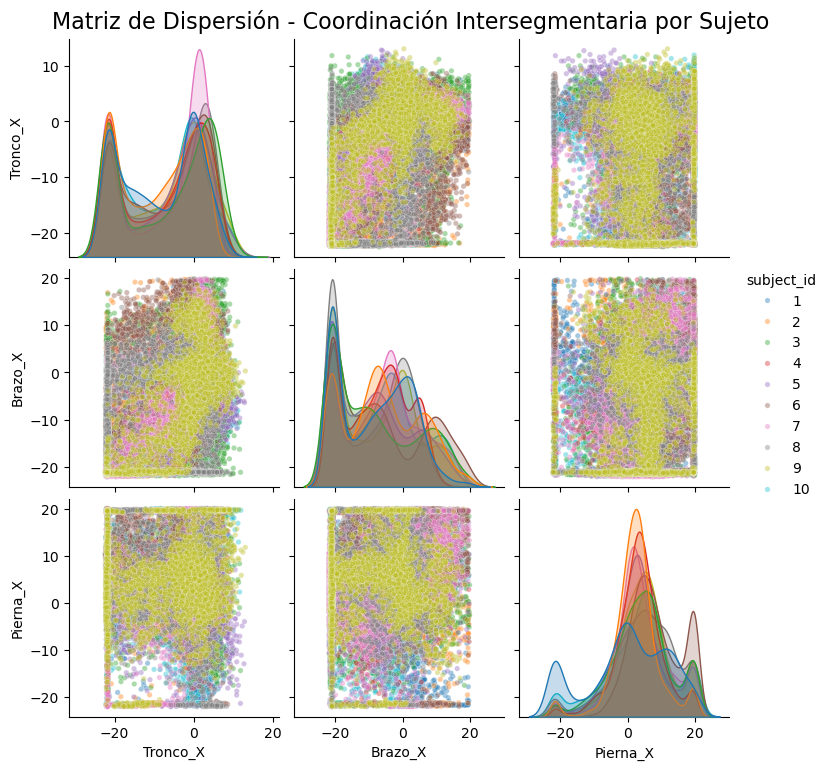

In [13]:
# Selección estratégica
sensores_estrategicos = [
    "chest_acc_x",   # Tronco
    "arm_acc_x",     # Brazo derecho
    "ankle_acc_x"    # Pierna
]

datos_scatter = DATASET_SENSORES_ACTIVIDAD[sensores_estrategicos + ["subject_id"]].copy()

datos_scatter.columns = [
    "Tronco_X",
    "Brazo_X",
    "Pierna_X",
    "subject_id"
]

# Convertir a categoría (importante para que seaborn lo trate como grupo)
datos_scatter["subject_id"] = datos_scatter["subject_id"].astype("category")

# Pairplot con color por sujeto
sns.pairplot(
    datos_scatter,
    vars=["Tronco_X", "Brazo_X", "Pierna_X"],
    hue="subject_id",
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 15}
)

plt.suptitle(
    'Matriz de Dispersión - Coordinación Intersegmentaria por Sujeto',
    y=1.02,
    fontsize=16
)

plt.show()